In [33]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

In [54]:
kappa=1e-1
NSTEPS=10

CFL max = 0.81; CFL min = 0.81
Solving AdvectionDiffusion1D by using PRK2-IMEX2
Shape of u: (81, 11)
Mass ini = 1.0112098164471395 and mass end = 1.0112098164471368


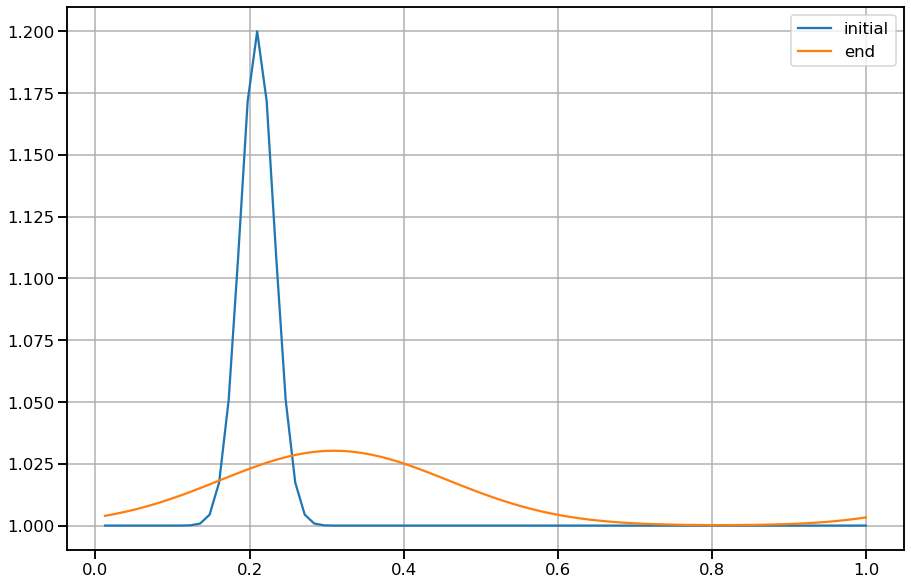

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_f =
[0.25 0.25 0.25 0.25]
c_f =
[0.  0.5 0.5 1. ]
A_s =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_s =
[0.25 0.25 0.25 0.25]
c_s =
[0.  0.5 0.5 1. ]
At =
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.5 0.5 0.5]]
bt =
[0.25 0.25 0.25 0.25]
ct =
[0. 0. 0. 2.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [55]:
solver=None
solver=DESolver()
solver.set_info(0)

mx=81

Flux_c=1.
Flux_cv=np.zeros((1,mx))
Flux_cv[:]=1.
Flux_cv[0,5:int(mx/2.)-5]=1.


#Flux_c=0.
#Flux_cv=np.zeros((1,mx))

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa}



rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})
def rhs(t,y,ctx):
    x1,_=problem.rhs_e(t,y,ctx)
    x2,j2=problem.rhs_mr_implicit(t,y,ctx)
    return x1+x2, j2

#solver.set_rhs(rhs)
#solver.set_method('RK4')
solver.set_method('PRK2-IMEX2')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
#solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.01    
problem_setup['T_DURATION']['end']=0.5
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))


solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

CFL max = 0.081; CFL min = 0.081
Solving AdvectionDiffusion1D by using PRK2-IMEX
Shape of u: (81, 101)
Mass ini = 1.0112098164471395 and mass end = 1.0112098164471373


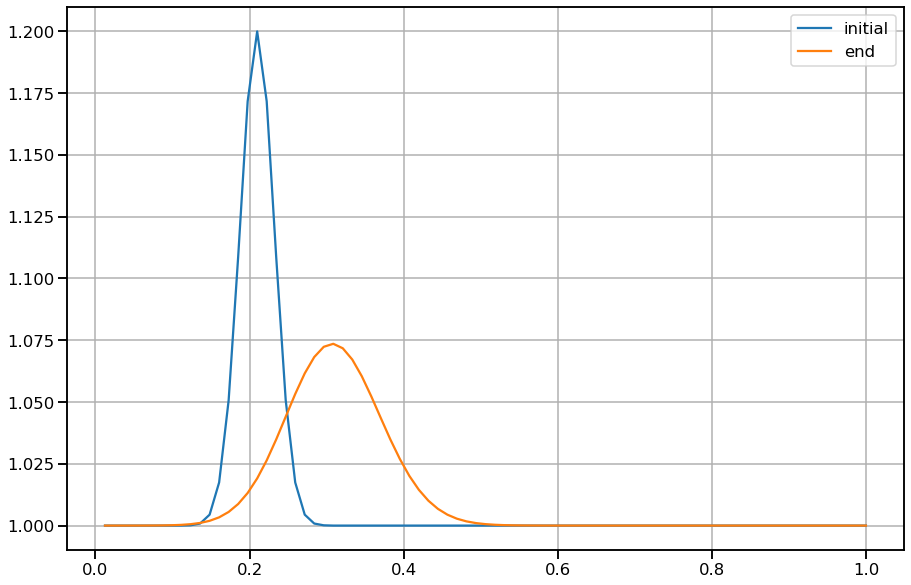

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_f =
[0.25 0.25 0.25 0.25]
c_f =
[0.  0.5 0.5 1. ]
A_s =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_s =
[0.25 0.25 0.25 0.25]
c_s =
[0.  0.5 0.5 1. ]
At =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [1. 1. 1. 1.]]
bt =
[0.25 0.25 0.25 0.25]
ct =
[0. 0. 0. 4.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [4]:
solver=None
solver=DESolver()
solver.set_info(0)

mx=81

Flux_c=1.
Flux_cv=np.zeros((1,mx))
Flux_cv[:]=1.
Flux_cv[0,5:int(mx/2.)-5]=1.

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa}

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})

#solver.set_method('RK4')
solver.set_method('PRK2-IMEX')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
#solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.001    
problem_setup['T_DURATION']['end']=0.5
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))


solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

CFL max = 0.081; CFL min = 0.081
Solving AdvectionDiffusion1D by using ARK4


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Shape of u: (81, 101)
Mass ini = 1.0112098164471395 and mass end = 1.0112098164471368


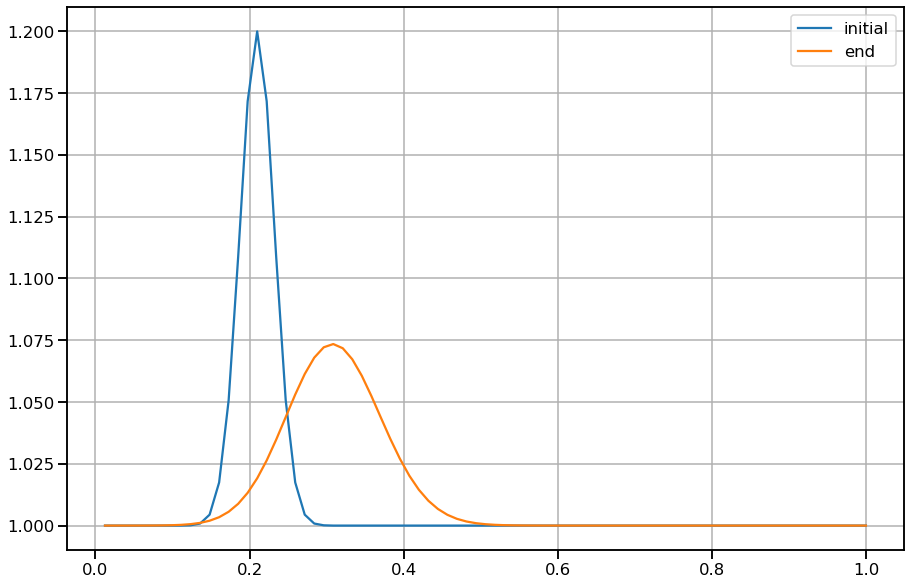

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.5         0.          0.          0.          0.          0.        ]
 [ 0.221776    0.110224    0.          0.          0.          0.        ]
 [-0.0488466  -0.17772065  0.84656725  0.          0.          0.        ]
 [-0.15541686 -0.35670501  1.05872588  0.30339599  0.          0.        ]
 [ 0.20142435  0.00874206  0.15993996  0.40382906  0.22606457  0.        ]]
b =
[ 0.1579163   0.          0.18675894  0.6805653  -0.27524053  0.25      ]
c =
[0.    0.5   0.332 0.62  0.85  1.   ]
At =
[[ 0.          0.          0.          0.          0.          0.        ]
 [ 0.25        0.25        0.          0.          0.          0.        ]
 [ 0.137776   -0.055776    0.25        0.          0.          0.        ]
 [ 0.14463687 -0.22393191  0.44929504  0.25        0.          0.        ]
 [ 0.09825878 -

['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [5]:
solver=None
solver=DESolver()
solver.set_info(0)

mx=81

Flux_c=1.
Flux_cv=np.zeros((1,mx))
Flux_cv[:]=1.
Flux_cv[0,5:int(mx/2.)-5]=1.

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa}

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

#solver.set_rhs(rhs_e)
#solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})

#solver.set_method('RK4')
#solver.set_method('MPRK2-IMEX')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
solver.set_method('ARK4')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.001    
problem_setup['T_DURATION']['end']=0.5
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))


solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()

CFL max = 0.081; CFL min = 0.081
Solving AdvectionDiffusion1D by using ARK-IMEX-MR2-AStable


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Shape of u: (81, 101)
Mass ini = 1.0112098164471395 and mass end = 1.0112098164471377


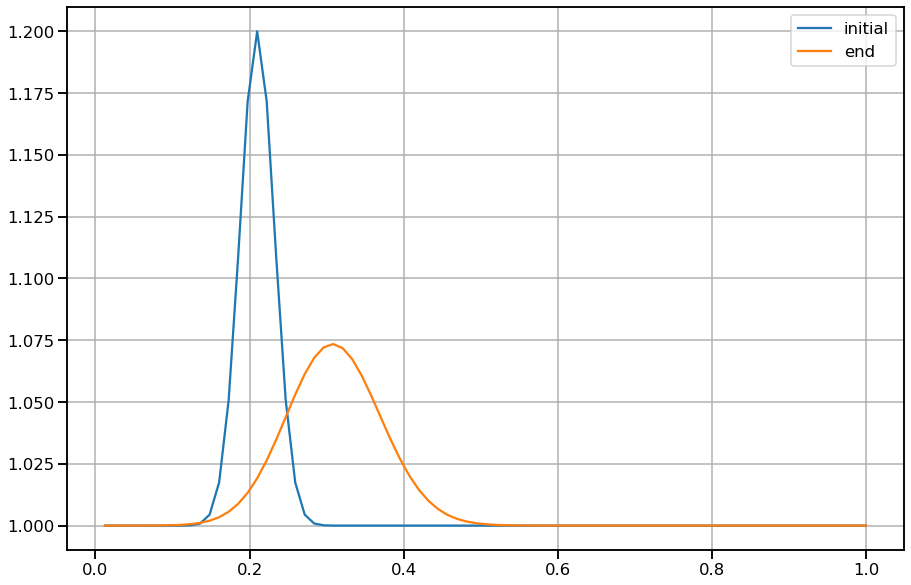

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0. 0.]
 [1. 0.]]
b =
[0.5 0.5]
c =
[0. 1.]
At =
[[0.  0. ]
 [0.5 0.5]]
bt =
[0.5 0.5]
ct =
[0. 1.]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2-AStable',
 'ARK-IMEX-MR2',
 'ARK-IMEX-Mix-1-1',
 'ARK-IMEX-Mix-2-1',
 'ARK-IMEX-Mix-2-2',
 'ARK-IMEX-Mix-2-2-c',
 'ARK-IMEX-Mix-2-1-c',
 'ARK-IMEX-Mix-4-1',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK-IMEX-Mix-3-1',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'PRK2-IMEX',
 'PRK2-IMEX2',
 'MPRK2-IMEX',
 'MPRK2-IMEX2',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [6]:
solver=None
solver=DESolver()
solver.set_info(0)

mx=81

Flux_c=1.
Flux_cv=np.zeros((1,mx))
Flux_cv[:]=1.
Flux_cv[0,5:int(mx/2.)-5]=1.

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':kappa}

rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

#solver.set_rhs(rhs_e)
#solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})

#solver.set_method('RK4')
#solver.set_method('MPRK2-IMEX')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
solver.set_method('ARK-IMEX-MR2-AStable')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.001    
problem_setup['T_DURATION']['end']=0.5
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))


solver.set_max_steps(NSTEPS)
solver.solve()

t,u=solver.get_trajectory()
print("Shape of u: {:}".format(u.shape))
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

solver.view_complete_status()